# T2S Pipeline

Thin orchestrator: every cell just calls into a decoupled module and names its output via `results.py`. No modeling/training logic lives in this notebook — that all lives in the `.py` files, where it's unit-tested (`tests/`).

Expert policy pretraining is **skipped** — assumed already done, checkpoints under `train_res/expertPolicy/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.getcwd())

# autoreload only tracks modules imported AFTER it is enabled, so drop any
# already-cached pipeline modules first. This is the stale-module problem that
# has produced repeated 'module has no attribute X' errors after file swaps.
for _m in ('config', 'results', 'env_utils', 'data_collection', 'dataset_audit',
            't2s_model', 't2s_targets', 't2s_io', 't2s_train', 't2s_predict', 't2s_eval',
            'reward_fn', 'policy_env', 'policy_train', 'rl_common', 'reward_preview',
            'progress', 'visualize', 'expert_train'):
    sys.modules.pop(_m, None)

import config
import results
config.ensure_dirs()
print('root:', config.ROOT_DIR)

root: d:\!DUKE\2026_Fall\Independent_Research\grl-t2s


## 1. Expert Policy Pretraining

Checkpoints live in `config.EXPERT_POLICY_DIR` = `train_res/expertPolicy/<config.EXPERT_RUN_NAME>/`, alongside `eval_history.json`. Toggle `RUN_EXPERT_TRAINING = False` (default) to just verify an existing run is there; `True` trains into that same folder.

In [ ]:
import expert_train, glob

RUN_EXPERT_TRAINING = False   # set True to actually train into config.EXPERT_POLICY_DIR

expert_run_dir = config.EXPERT_POLICY_DIR   # train_res/expertPolicy/<EXPERT_RUN_NAME>/
os.makedirs(expert_run_dir, exist_ok=True)

if RUN_EXPERT_TRAINING:
    results.new_run_dir('expert_policy', config.EXPERT_RUN_NAME, meta={'task_name': config.TASK_NAME})
    model, expert_history = expert_train.train_expert_policy(expert_run_dir)
    print('trained expert, final success rate:', expert_history[-1] if expert_history else None)
else:
    ckpts = glob.glob(os.path.join(expert_run_dir, f'{config.TASK_SLUG}_*.zip'))
    assert ckpts, (f'no expert checkpoints found in {expert_run_dir} for task {config.TASK_NAME} — '
                    'place them there (see chat for the rename command) or set RUN_EXPERT_TRAINING=True')
    print(f'reusing {len(ckpts)} expert checkpoints from {expert_run_dir}')

## 2. T2S Data Collection

In [4]:
import data_collection
from env_utils import ensure_fixed_task

ensure_fixed_task()

DATA_RUN_NAME = 'v7'          # bump: v7 predates the success-frame off-by-one fix
data_run_dir = results.new_run_dir('data_collection', DATA_RUN_NAME,
                                     meta={'notes': 'off-by-one success frame fixed; wider coverage'})

In [ ]:


plan = data_collection.default_collection_plan(
    expert_policy_dir=expert_run_dir,
    include_noise_variants=True,
    include_random_policy=True,     # off-path coverage: the model currently has no
                                     # data anywhere an untrained policy starts
)

summary = data_collection.collect_dataset(
    data_run_dir, plan=plan,
    expert_policy_dir=expert_run_dir,        # REQUIRED: collect_dataset probes for a
                                              # failure source itself
    failure_noise_candidates=(0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0),
    failure_max_success_rate=0.4,
    n_failure_episodes=40,
)
print(summary)

### 2b. Dataset audit — check before training on it

Checks for the defects that have actually occurred here: off-by-one success labelling (a `0 -> 0` boundary instead of `1 -> 0`), zero/thin failure coverage (which makes the `succ` and `all` conditions train identical models), and missing exploration-region states (which produces flat extrapolated predictions and a dead reward).

Cheap, and catches problems before hours of T2S training and RL sweeps.

In [5]:
import dataset_audit

audit = dataset_audit.audit_dataset(
    os.path.join(data_run_dir, 'dataset.npz'),
    summary_path=os.path.join(data_run_dir, 'dataset_summary.json'))

flagged = [k for k in ('success_boundary', 'failure_coverage', 'exploration_coverage',
                        'object_movement', 'label_sanity')
            if audit[k]['verdict'] != 'OK']
if flagged:
    print(f'>>> {len(flagged)} check(s) flagged: {flagged}')
    print('>>> Fix data collection before training on this dataset.')
else:
    print('>>> all checks passed')

dataset: d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\data_collection\v7\dataset.npz
  rows=111,000 obs_dim=39 (config match: True)

[ok  ] success-frame labelling: OK
         episodes_with_correct_boundary = 128
         episodes_with_bad_boundary = 0
         bad_examples = []
         successful_episodes_without_zero = 0

[ok  ] failure coverage: OK
         total_episodes = 222
         failed_episodes = 94
         failed_episode_fraction = 0.4234
         failed_row_fraction = 0.4234

[ok  ] exploration-region coverage: OK
         hand_peg_min = 0.0033
         hand_peg_max = 0.7539
         hand_peg_median = 0.1708
         frac_hand_near_object = 0.1871
         frac_hand_far_from_object = 0.4734

[ok  ] object manipulation: OK
         episodes_with_object_moved = 222
         total_episodes = 222
         object_moved_fraction = 1.0000

[ok  ] label sanity: OK
         censor_label = 300.0000
         max_steps = 500
         longest_episode = 500
         cens

In [9]:
import numpy as np, progress
d = np.load(os.path.join(data_run_dir, 'dataset.npz'))
X, y, ep = d['X'], d['y_steps'], d['episode_ids']

first_zero_dist, next_dist, prev_dist = [], [], []
for e in np.unique(ep):                      # ALL episodes, not the first 40
    idx = np.flatnonzero(ep == e)
    ye = y[idx]
    z = np.flatnonzero(ye == 0.0)
    if len(z) == 0:
        continue                             # failed episode
    k = z[0]
    dist = progress.peg_goal_distance_curve(X[idx])
    if k == 0 or k + 1 >= len(idx):
        continue
    prev_dist.append(dist[k - 1])
    first_zero_dist.append(dist[k])
    next_dist.append(dist[k + 1])

print(f"episodes examined: {len(first_zero_dist)}")
print(f"frame k-1 (label 1): peg-goal = {np.mean(prev_dist):.5f}")
print(f"frame k   (label 0): peg-goal = {np.mean(first_zero_dist):.5f}")
print(f"frame k+1 (label 0): peg-goal = {np.mean(next_dist):.5f}")

episodes examined: 128
frame k-1 (label 1): peg-goal = 0.19696
frame k   (label 0): peg-goal = 0.19249
frame k+1 (label 0): peg-goal = 0.18744


## 3. T2S Model Training (MC / TD(0) / TD(&lambda;))

In [ ]:
import t2s_train

T2S_RUN_NAME = 'v1'
t2s_run_dir = results.new_run_dir('t2s_model', T2S_RUN_NAME,
                                    meta={'data_run': DATA_RUN_NAME})
dataset_path = os.path.join(data_run_dir, 'dataset.npz')

models, histories, summary_rows = t2s_train.run_all_combos(
    t2s_run_dir, dataset_path, seeds=(0,))
for row in summary_rows:
    print(row['combo'], 'mean val MSE:', round(row['mean_val_mse'], 1))

## 4. T2S Model Analysis (held-out policies — never in training data)

In [13]:
from stable_baselines3 import SAC

# checkpoints that were NEVER used in data collection (see Section 2's `checkpoints=[...]`)
eval_success_pol = SAC.load('train_res/expertPolicy/peg-insert/peg_insert_side_v3_700000.zip')
eval_failure_pol = SAC.load('train_res/expertPolicy/peg-insert/peg_insert_side_v3_200000.zip')

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


combo                      mae          rmse     pearson_r  spearman_rhomax_wrong_direction
-------------------------------------------------------------------------------------------
mc_succ                 9.8088       14.8061        0.9446        0.9447        6.4703
mc_all                  9.5247       18.0594        0.8998        0.9396        9.7316
td0_succ                5.3007        7.9864        0.9905        0.9827        1.4558
td0_all                 4.4700        5.8115        0.9786        0.9873        0.0775
tdlambda_succ           7.5759       11.5298        0.9752        0.9574        3.9338
tdlambda_all            8.2707       19.0776        0.9006        0.9855        1.8698


d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\t2s_eval.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos, rotation=45, ha="right")
d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\t2s_eval.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos, rotation=45, ha="right")
d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\t2s_eval.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos, rotation=45, ha="right")
d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\t2s_eval.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos, rotation=45, ha="right")


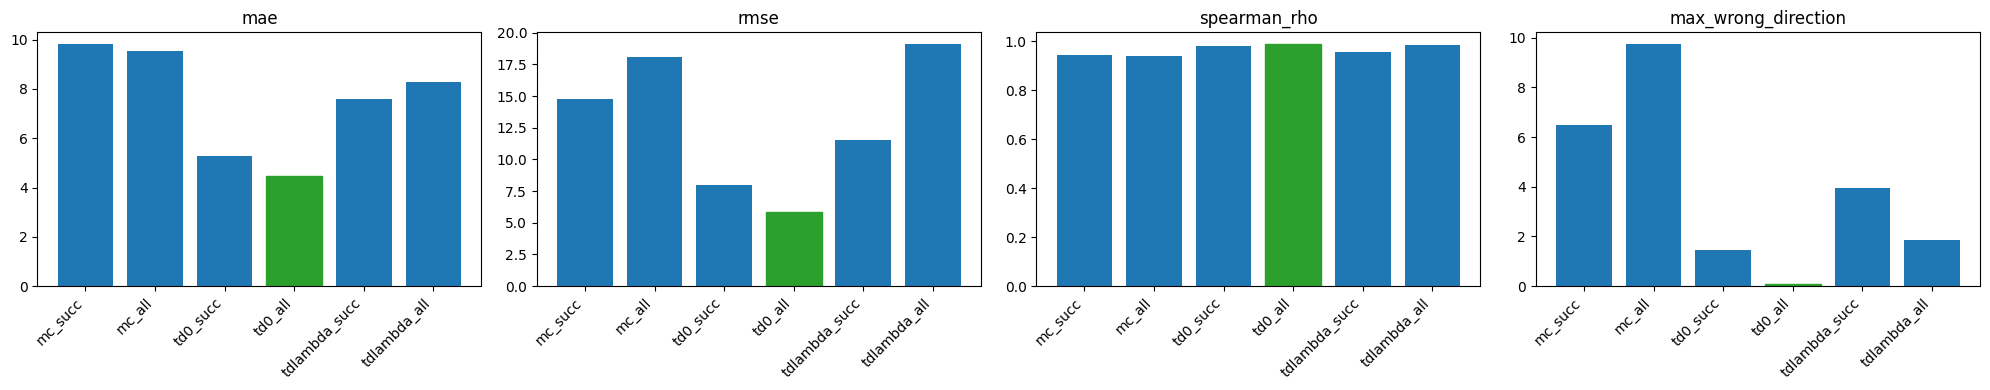

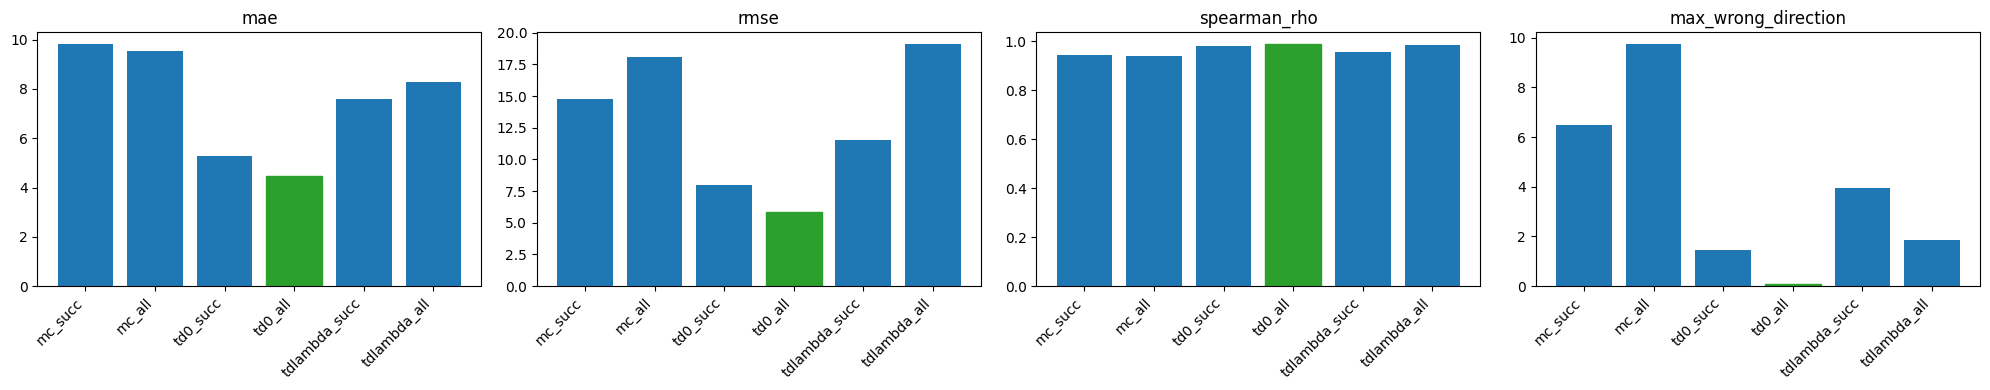

In [14]:
import json
import t2s_predict, t2s_eval
from stable_baselines3 import SAC

EVAL_RUN_NAME = 'v1'
eval_run_dir = results.new_run_dir('t2s_eval', EVAL_RUN_NAME, meta={'t2s_run': T2S_RUN_NAME})

reports = {}
for combo in summary_rows:
    method, condition = combo['combo'].rsplit('_', 1)
    predict_fn = t2s_predict.load_t2s_predictor(t2s_run_dir, method, condition, seed=combo['best_seed'])
    reports[combo['combo']] = t2s_eval.run_full_evaluation(predict_fn, eval_success_pol, eval_failure_pol)

with open(os.path.join(eval_run_dir, 'eval_report.json'), 'w') as f:
    json.dump(reports, f, indent=2)
print(t2s_eval.format_report_table(reports))

t2s_eval.plot_combo_comparison(reports, save_path=os.path.join(eval_run_dir, 'combo_comparison.png'))

### 4c. Two sample trajectories — visual check that every model can predict

Rolls out exactly two reference trajectories (one succeeding, one failing) from the held-out policies, then overlays **every** T2S model's predictions on those *same* states. Same trajectory for all models, so any difference in the curves is the model, not the rollout.

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


success: 73 steps, success_step=52
failure: 500 steps, success_step=None


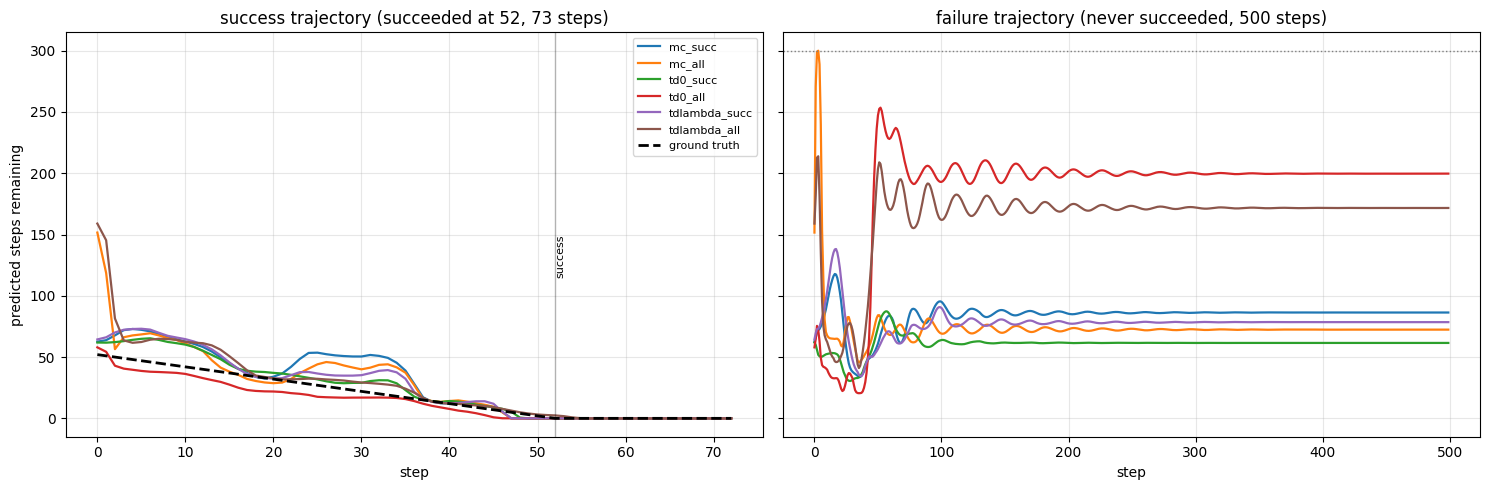

In [36]:
import t2s_eval, t2s_predict

# same held-out policies Section 4 used — must not appear in data collection
trajectories = t2s_eval.collect_eval_trajectories(eval_success_pol, eval_failure_pol, seed=500)
for scenario, traj in trajectories.items():
    print(f"{scenario}: {len(traj['obs'])} steps, success_step={traj['success_step']}")

# one predictor per combo, all evaluated on the SAME stored observations
predictors = {}
for row in summary_rows:
    method, condition = row['combo'].rsplit('_', 1)
    predictors[row['combo']] = t2s_predict.load_t2s_predictor(
        t2s_run_dir, method, condition, seed=row['best_seed'])

t2s_eval.plot_sample_trajectories(
    trajectories, predictors,
    save_path=os.path.join(eval_run_dir, 'sample_trajectories.png'));

## 4b. Resume point — run this after a kernel restart

Rebuilds everything Section 5 needs (`t2s_run_dir`, `summary_rows`, `reports`) from files already on disk, so you can jump straight to downstream RL without re-running Stages 1-4. Run the first cell of the notebook (imports) first, then this, then Section 5.

In [10]:
import json, os
import t2s_predict, t2s_eval, t2s_io

# --- point these at the runs you already completed ---
T2S_RUN_NAME  = 'v1'
EVAL_RUN_NAME = 'v1'

t2s_run_dir  = results.get_run_dir('t2s_model', T2S_RUN_NAME)
eval_run_dir = results.get_run_dir('t2s_eval', EVAL_RUN_NAME)

# rebuild summary_rows from the Stage 3 manifest (not recomputed — just read back)
manifest = t2s_io.load_manifest(t2s_run_dir)
summary_rows = [
    dict(combo=combo, mean_val_mse=info['mean_val_mse'], std_val_mse=info['std_val_mse'],
         seeds_val_mse=info['per_seed_val_mse'],
         mean_val_mse_succ_only=info['mean_val_mse_succ_only'],
         best_seed=info['best_seed'])
    for combo, info in manifest['combos'].items()
]

# rebuild reports from the Stage 4 eval report
with open(os.path.join(eval_run_dir, 'eval_report.json')) as f:
    reports = json.load(f)

print(f'resumed: {len(summary_rows)} combos from {t2s_run_dir}')
print(f'         {len(reports)} eval reports from {eval_run_dir}')
print()
print(t2s_eval.format_report_table(reports))

resumed: 6 combos from d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\t2s_model\v1
         6 eval reports from d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\t2s_eval\v1

combo                      mae          rmse     pearson_r  spearman_rhomax_wrong_direction
-------------------------------------------------------------------------------------------
mc_succ                 9.8088       14.8061        0.9446        0.9447        6.4703
mc_all                  9.5247       18.0594        0.8998        0.9396        9.7316
td0_succ                5.3007        7.9864        0.9905        0.9827        1.4558
td0_all                 4.4700        5.8115        0.9786        0.9873        0.0775
tdlambda_succ           7.5759       11.5298        0.9752        0.9574        3.9338
tdlambda_all            8.2707       19.0776        0.9006        0.9855        1.8698


---
# 5. Downstream RL — configuration

**Everything downstream is configured here and nowhere else.** Sections 6-8 read these variables; none of them re-select a model or override a parameter. Change something here and re-run 5 -> 6 -> 7 -> 8.

Requires `t2s_run_dir` and `summary_rows` — from Section 3, or from the 4b resume cell after a kernel restart.

In [37]:
import t2s_predict

# ---------------- WHAT TO TRAIN ----------------
COMBOS      = ['td0_all']          # T2S models to train with (1 or more)
SEEDS       = [0, 1, 2]              # RL seeds; scene is fixed so this varies SAC only
REWARD_MODE = 'difference'           # 'difference' (potential-based) or 'absolute' or "difference_timed"
TIMESTEPS   = 200_000
SWEEP_NAME  = 'sweep_v3_difference'

# ---------------- T2S CHECKPOINT SELECTION ----------------
# by default use the best Stage-3 seed per combo; override any entry manually
T2S_SEEDS = {r['combo']: r['best_seed'] for r in summary_rows}
# e.g. T2S_SEEDS['td0_succ'] = 2

available = sorted(r['combo'] for r in summary_rows)
unknown = [c for c in COMBOS if c not in available]
assert not unknown, f'unknown combos {unknown}; available: {available}'

# one frozen predictor per configured combo — THIS is what sections 6 and 7 use
PREDICTORS = {}
for combo in COMBOS:
    method, condition = combo.rsplit('_', 1)
    PREDICTORS[combo] = t2s_predict.load_t2s_predictor(
        t2s_run_dir, method, condition, seed=T2S_SEEDS[combo])

print(f'configured {len(COMBOS)} combo(s) x {len(SEEDS)} seed(s) = '
      f'{len(COMBOS)*len(SEEDS)} runs @ {TIMESTEPS:,} steps, reward_mode={REWARD_MODE!r}')
for c in COMBOS:
    print(f"  {c:16s} t2s seed {T2S_SEEDS[c]}")

configured 1 combo(s) x 3 seed(s) = 3 runs @ 200,000 steps, reward_mode='difference'
  td0_all          t2s seed 0


---
# 6. Reward preview (no training)

Replays two reference trajectories through the reward arithmetic for **exactly the models configured in Section 5**, so you see the real reward signal before spending compute.

**`return_gap` is the go/no-go gate**: success-trajectory return minus failure-trajectory return. If a reward gives similar returns to a trajectory that succeeds and one that never does, no training budget can make RL prefer success.

In [38]:
import reward_preview, t2s_eval

# collect the two reference trajectories if 4c hasn't already (self-contained)
if 'trajectories' not in dir():
    trajectories = t2s_eval.collect_eval_trajectories(eval_success_pol, eval_failure_pol, seed=500)
for scenario, traj in trajectories.items():
    print(f"{scenario}: {len(traj['obs'])} steps, success_step={traj['success_step']}")
print()

# previews BOTH reward modes so you can sanity-check the Section 5 choice
preview = reward_preview.preview_reward(trajectories, PREDICTORS,
                                         reward_modes=('absolute', 'difference'))
print(reward_preview.format_preview_table(preview))
print()
print('return gap : success return - failure return  (want LARGE POSITIVE)')
print('dead% s/f  : fraction of ~zero-reward steps    (want LOW, esp. failure)')
print('align      : Spearman(reward, peg-dist reduction) (want POSITIVE)')

chosen = [(c, m) for (c, m) in preview if m == REWARD_MODE]
print(f'\n--- configured mode ({REWARD_MODE}) ---')
for key in chosen:
    gap = preview[key].get('return_gap')
    verdict = 'OK' if (gap or 0) > 0 else 'NEGATIVE GAP — reward prefers the failing trajectory'
    print(f'  {key[0]:16s} return_gap={gap:,.1f}  {verdict}')

success: 73 steps, success_step=52
failure: 500 steps, success_step=None

combo           mode         return gap   succ ret   fail ret     dead% s/f   align
-----------------------------------------------------------------------------------
td0_all         absolute        92259.3    -1012.2   -93271.5     0.35/0.00    0.07
td0_all         difference        199.7       57.9     -141.8     0.33/0.02   -0.03

return gap : success return - failure return  (want LARGE POSITIVE)
dead% s/f  : fraction of ~zero-reward steps    (want LOW, esp. failure)
align      : Spearman(reward, peg-dist reduction) (want POSITIVE)

--- configured mode (difference) ---
  td0_all          return_gap=199.7  OK


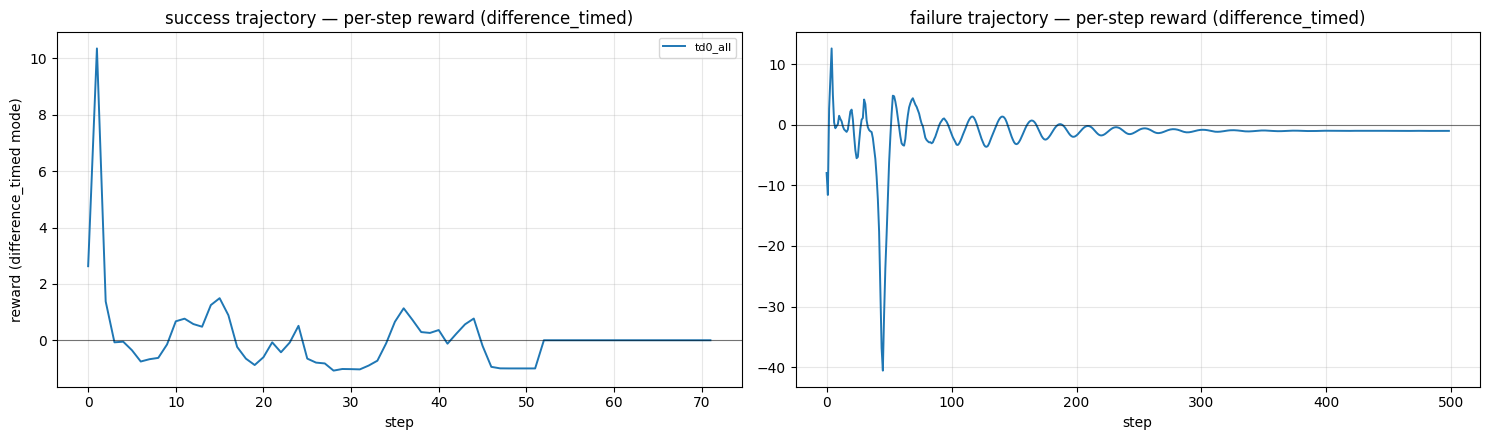

In [16]:
# per-step reward curves — a flat line at ANY level means no gradient
reward_preview.plot_reward_preview(
    trajectories, PREDICTORS, reward_mode=REWARD_MODE,
    save_path=os.path.join(eval_run_dir, f'reward_preview_{REWARD_MODE}.png'));

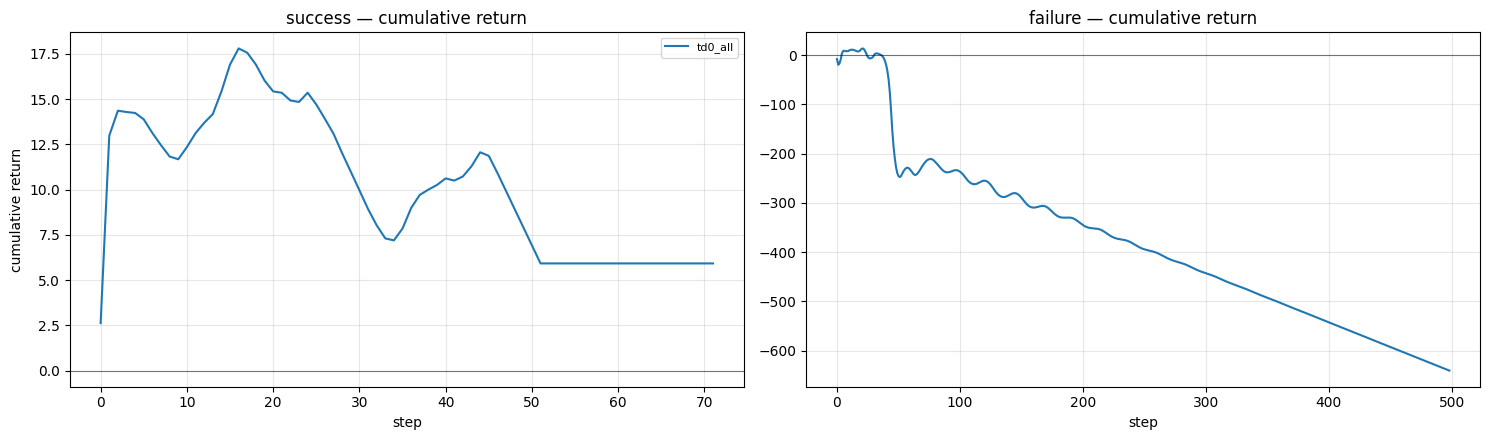

In [17]:
import numpy as np, matplotlib.pyplot as plt
import reward_preview

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, (scenario, traj) in zip(axes, trajectories.items()):
    for combo, fn in PREDICTORS.items():
        preds = np.array([fn(o) for o in traj['obs']])
        r = reward_preview.compute_step_rewards(preds, 'difference_timed')
        ss = traj.get('success_step')
        if ss is not None and len(r):
            r = r.copy(); r[ss:] = 0.0
        ax.plot(np.cumsum(r), label=combo)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax.set_title(f'{scenario} — cumulative return'); ax.set_xlabel('step')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('cumulative return'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
# 7. Train

Trains one policy per (combo, seed) from the Section 5 config. Resumable: a run whose `eval_history.json` already exists is loaded rather than retrained, so you can extend `SEEDS` later and only pay for the new ones.

In [18]:
import json
import policy_train

sweep_results = policy_train.run_sweep(
    t2s_run_dir, results, combos=COMBOS, seeds=SEEDS, t2s_seeds=T2S_SEEDS,
    sweep_name=SWEEP_NAME, reward_mode=REWARD_MODE, total_timesteps=TIMESTEPS,
    skip_existing=True,
    # ckpt_freq == eval_freq so EVERY logged eval point has a loadable
    # checkpoint. Previously ckpt_freq=50k vs eval_freq=10k meant peak-metric
    # steps (e.g. 80004) had no saved policy to inspect.
    ckpt_freq=10_000, eval_freq=10_000, n_eval_episodes=3,
)

sweep_rows = policy_train.summarize_sweep(sweep_results)
print()
print(policy_train.format_sweep_table(sweep_rows))

sweep_dir = results.new_run_dir('policy', SWEEP_NAME,
                                  meta={'kind': 'sweep_summary', 'combos': COMBOS,
                                        'seeds': SEEDS, 'reward_mode': REWARD_MODE,
                                        'timesteps': TIMESTEPS})
with open(os.path.join(sweep_dir, 'sweep_summary.json'), 'w') as f:
    json.dump({'rows': sweep_rows,
                'raw': {f'{c}|{s}': h for (c, s), h in sweep_results.items()}}, f, indent=2)
print(f'\nsaved to {sweep_dir}')

[1/3] sweep_v3_td0_all_seed0: training 200,000 steps
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v3_td0_all_seed0\policy_10002.zip
[eval @ 10002] succ=0.00 hand->peg=0.2144 peg->goal=0.4135 peg_moved=1.0 ctrl=0.0
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v3_td0_all_seed0\policy_20004.zip
[eval @ 20004] succ=0.00 hand->peg=0.2144 peg->goal=0.4135 peg_moved=1.0 ctrl=0.0
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v3_td0_all_seed0\policy_30000.zip
[eval @ 30000] succ=0.00 hand->peg=0.2144 peg->goal=0.4135 peg_moved=1.0 ctrl=0.0
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v3_td0_all_seed0\policy_40002.zip
[eval @ 40002] succ=0.00 hand->peg=0.2144 peg->goal=0.4135 peg_moved=1.0 ctrl=0.0
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v3_td0_all_seed0\policy_50004.zip
[eval @ 50004] succ=0.00 hand

C:\Users\Allen\AppData\Local\Temp\ipykernel_38768\3980067232.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos_plot, rotation=20, ha='right')


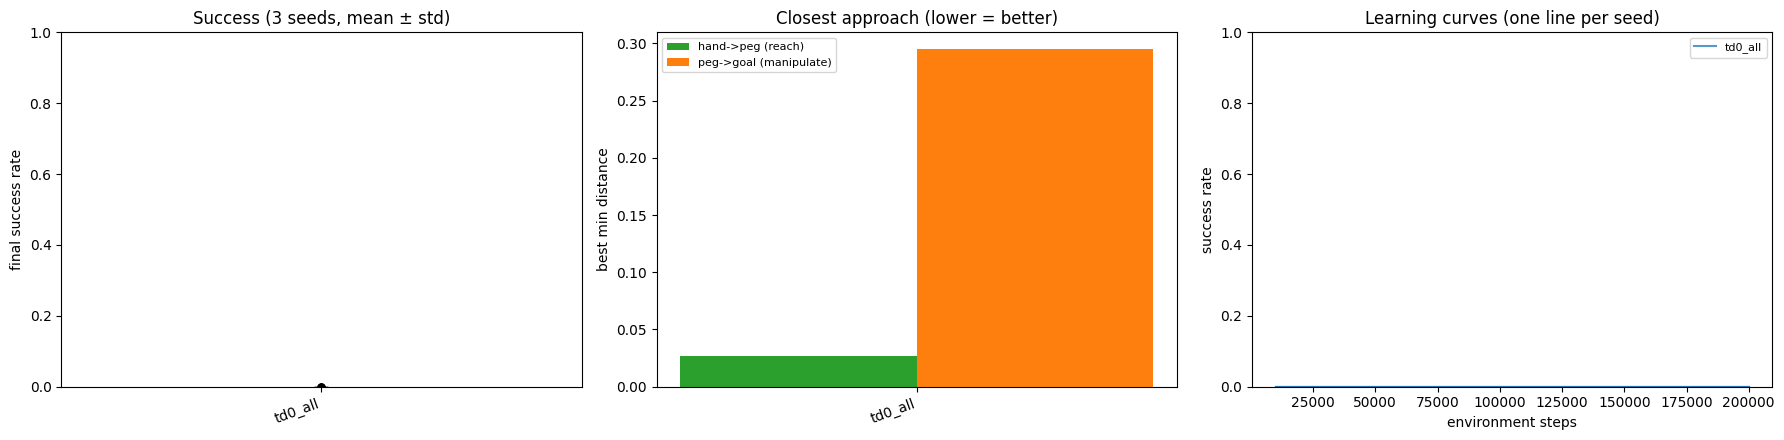

In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4.5))
combos_plot = [r['combo'] for r in sweep_rows]

# success rate, mean +/- std across seeds, individual seeds as dots
ax1.bar(combos_plot, [r['mean_final_success'] for r in sweep_rows],
         yerr=[r['std_final_success'] for r in sweep_rows], capsize=5, color='tab:blue')
for i, r in enumerate(sweep_rows):
    ax1.scatter([i]*len(r['per_seed_final_success']), r['per_seed_final_success'],
                 color='black', zorder=3, s=25)
ax1.set_ylabel('final success rate'); ax1.set_ylim(0, 1)
ax1.set_title(f'Success ({len(SEEDS)} seeds, mean ± std)')

# REACH phase (hand->peg) alongside MANIPULATION phase (peg->goal).
# peg->goal is blind to reaching: an arm that touches the peg but never grasps
# leaves the peg at its reset position, so peg->goal stays constant either way.
x = np.arange(len(combos_plot)); w = 0.38
hand = [r.get('best_min_hand_peg_distance') or 0 for r in sweep_rows]
peg  = [r.get('best_min_peg_goal_distance') or 0 for r in sweep_rows]
ax2.bar(x - w/2, hand, w, label='hand->peg (reach)', color='tab:green')
ax2.bar(x + w/2, peg,  w, label='peg->goal (manipulate)', color='tab:orange')
ax2.set_xticks(x)
ax2.set_ylabel('best min distance'); ax2.set_title('Closest approach (lower = better)')
ax2.legend(fontsize=8)

# learning curves, one line per (combo, seed)
colors = dict(zip(COMBOS, ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']))
for (combo, sd), history in sweep_results.items():
    if not history:
        continue
    ax3.plot([h['step'] for h in history], [h['success_rate'] for h in history],
              color=colors.get(combo, 'gray'), alpha=0.75,
              label=combo if sd == SEEDS[0] else None)
ax3.set_xlabel('environment steps'); ax3.set_ylabel('success rate'); ax3.set_ylim(0, 1)
ax3.set_title('Learning curves (one line per seed)'); ax3.legend(fontsize=8)

for ax in (ax1, ax2):
    ax.set_xticklabels(combos_plot, rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(sweep_dir, 'sweep_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
import json, glob, os
import numpy as np
import progress
from env_utils import make_fixed_scene_env

# --- baseline: distance at reset, and under a random policy ---
env = make_fixed_scene_env()
obs, _ = env.reset(seed=0)
print(f"peg-goal distance at reset:        {progress.peg_goal_distance(obs):.4f}")

rand_obs = [obs.copy()]
for _ in range(500):
    obs, _, term, trunc, _ = env.step(env.action_space.sample())
    rand_obs.append(obs.copy())
    if term or trunc: break
env.close()
m = progress.compute_progress_metrics(np.array(rand_obs), None)
print(f"random policy min distance:        {m['min_peg_goal_distance']:.4f}")
print(f"random policy obs_movement:        {m['obs_movement']:.1f}")
print(f"random policy achieved control:    {m.get('achieved_control')}")

# --- what your trained runs actually recorded ---
print("\nper-run final eval:")
for path in sorted(glob.glob(os.path.join('train_res', 'policy', f'{SWEEP_NAME}_*', 'eval_history.json'))):
    h = json.load(open(path))
    if not h: continue
    last = h[-1]
    name = os.path.basename(os.path.dirname(path))
    print(f"  {name:34s} n_evals={len(h):3d} "
          f"min_d={last.get('mean_min_peg_goal_distance')} "
          f"ctrl={last.get('control_rate')} "
          f"move={last.get('mean_obs_movement')}")

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


peg-goal distance at reset:        0.4135
random policy min distance:        0.4135
random policy obs_movement:        15.5
random policy achieved control:    False

per-run final eval:
  sweep_v3_td0_all_seed0             n_evals= 20 min_d=0.34477250238746215 ctrl=1.0 move=5.910551820561779
  sweep_v3_td0_all_seed1             n_evals= 20 min_d=0.413543889020503 ctrl=0.0 move=2.770669577711928
  sweep_v3_td0_all_seed2             n_evals= 20 min_d=0.413543889020503 ctrl=0.0 move=4.26886445290755


In [22]:
import json, glob, os
for path in sorted(glob.glob(os.path.join('train_res','policy','sweep_v3_*','eval_history.json'))):
    h = json.load(open(path))
    if not h: continue
    name = os.path.basename(os.path.dirname(path))
    best_ctrl = max((e.get('control_rate') or 0) for e in h)
    best_d = min((e.get('mean_min_peg_goal_distance') or 9e9) for e in h)
    print(f"{name:36s} best_ctrl={best_ctrl:.2f} best_min_d={best_d:.4f}")

sweep_v3_td0_all_seed0               best_ctrl=1.00 best_min_d=0.2949
sweep_v3_td0_all_seed1               best_ctrl=1.00 best_min_d=0.4024
sweep_v3_td0_all_seed2               best_ctrl=1.00 best_min_d=0.4135


---
# 8. Check a trained policy

Load any policy produced above (or any other checkpoint) and look at what it actually does: rollout video, and the T2S prediction curve it was trained against.

Defaults to the best run from Section 7; override `CHECK_RUN` / `CHECK_CKPT` to inspect anything else, including expert checkpoints.

### Search for the best checkpoint

In [23]:
import json, glob, os
for path in sorted(glob.glob(os.path.join('train_res','policy','sweep_v3_td0_all_*','eval_history.json'))):
    h = json.load(open(path))
    name = os.path.basename(os.path.dirname(path))
    peak = max(h, key=lambda e: (e.get('control_rate') or 0))
    print(f"\n{name}")
    print(f"  peak ctrl={peak.get('control_rate')} at step {peak['step']}, "
          f"min_d={peak.get('mean_min_peg_goal_distance')}")
    print(f"  final   ctrl={h[-1].get('control_rate')} at step {h[-1]['step']}")
    # trace when control was held
    held = [e['step'] for e in h if (e.get('control_rate') or 0) > 0]
    print(f"  control achieved at steps: {held[:10]}{'...' if len(held)>10 else ''} ({len(held)}/{len(h)} evals)")


sweep_v3_td0_all_seed0
  peak ctrl=1.0 at step 80004, min_d=0.413543889020503
  final   ctrl=1.0 at step 200004
  control achieved at steps: [80004, 120000, 130002, 140004, 150000, 160002, 170004, 180000, 190002, 200004] (10/20 evals)

sweep_v3_td0_all_seed1
  peak ctrl=1.0 at step 50004, min_d=0.413543889020503
  final   ctrl=0.0 at step 200004
  control achieved at steps: [50004, 60000, 100002, 110004, 120000, 130002, 140004, 150000, 160002, 170004] (10/20 evals)

sweep_v3_td0_all_seed2
  peak ctrl=1.0 at step 70002, min_d=0.413543889020503
  final   ctrl=0.0 at step 200004
  control achieved at steps: [70002, 90000, 100002, 120000, 130002, 140004, 150000, 160002, 170004] (9/20 evals)


In [24]:
import sys
sys.modules.pop('progress', None)
import progress
print('has new metrics:', 'min_hand_peg_distance' in progress.compute_progress_metrics.__doc__ or
      hasattr(progress, 'hand_peg_distance'))

has new metrics: True


In [27]:
import glob, os
import numpy as np
import visualize, progress

for run in sorted(glob.glob(os.path.join('train_res','policy','sweep_v3_td0_all_*'))):
    name = os.path.basename(run)
    for ckpt in ('policy_80004.zip',):   # add a peak-step ckpt here too
        path = os.path.join(run, ckpt)
        if not os.path.exists(path):
            continue
        policy, _ = visualize.load_policy(ckpt, run)
        for sd in (0, 1):
            r = visualize.rollout(policy, predict_t2s=None, seed=sd)
            m = progress.compute_progress_metrics(r['obs'], r['success_step'])
            print(f"{name} {ckpt} seed{sd}: "
                  f"hand->peg={m['min_hand_peg_distance']:.4f} "
                  f"peg_moved={m['peg_moved']} drift={m['peg_max_drift']:.6f} "
                  f"ctrl_detector={m['achieved_control']}")

sweep_v3_td0_all_seed0 policy_80004.zip seed0: hand->peg=0.0279 peg_moved=True drift=0.037589 ctrl_detector=True
sweep_v3_td0_all_seed0 policy_80004.zip seed1: hand->peg=0.0279 peg_moved=True drift=0.037589 ctrl_detector=True
sweep_v3_td0_all_seed1 policy_80004.zip seed0: hand->peg=0.0925 peg_moved=True drift=0.007383 ctrl_detector=False
sweep_v3_td0_all_seed1 policy_80004.zip seed1: hand->peg=0.0925 peg_moved=True drift=0.007383 ctrl_detector=False
sweep_v3_td0_all_seed2 policy_80004.zip seed0: hand->peg=0.0416 peg_moved=True drift=0.007383 ctrl_detector=False
sweep_v3_td0_all_seed2 policy_80004.zip seed1: hand->peg=0.0416 peg_moved=True drift=0.007383 ctrl_detector=False


loaded: d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\sweep_v3_td0_all_seed1\policy_50004.zip
t2s reward model: td0_all (seed 0)
  seed 1: FAILED (ran 500 steps without success) | T2S start=57.9 end=28.6 min=28.4 max_upward_jump=0.29


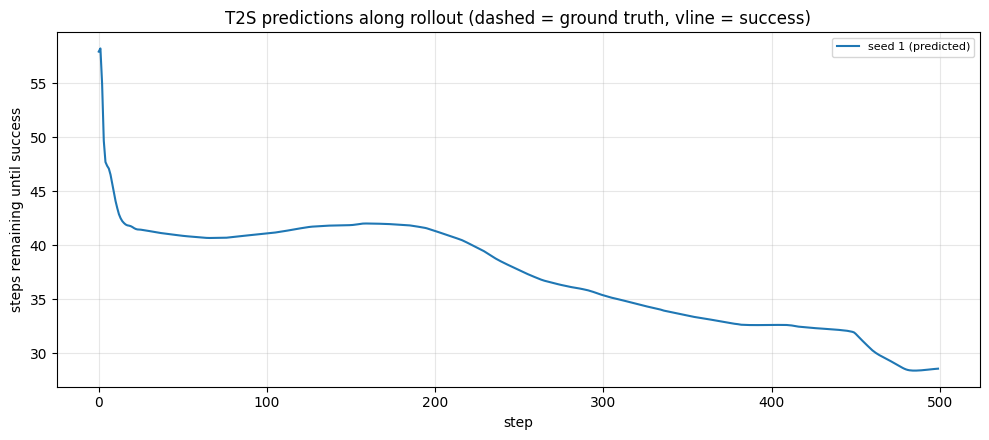

  seed 1: min_peg_goal_dist=0.4135 control=True obs_movement=0.90


In [32]:
import visualize

# defaults to the top-ranked combo from Section 7, first seed
CHECK_COMBO = sweep_rows[0]['combo'] if 'sweep_rows' in dir() and sweep_rows else COMBOS[0]
CHECK_SEED  = SEEDS[1]
CHECK_RUN   = f'{SWEEP_NAME}_{CHECK_COMBO}_seed{CHECK_SEED}'
CHECK_CKPT  = 'policy_50004.zip'      # or 'policy_<step>.zip'
SEEDS_TO_VIEW = [1]
RENDER_VIDEO  = True

check_dir = results.get_run_dir('policy', CHECK_RUN)
policy, resolved = visualize.load_policy(CHECK_CKPT, check_dir)
print('loaded:', resolved)
print('t2s reward model:', CHECK_COMBO, f'(seed {T2S_SEEDS[CHECK_COMBO]})')

predict_fn = PREDICTORS[CHECK_COMBO]   # the exact reward the policy trained against

rollouts = []
for sd in SEEDS_TO_VIEW:
    r = visualize.rollout(policy, predict_t2s=predict_fn, seed=sd, render=RENDER_VIDEO)
    rollouts.append(r)
    print(f'  seed {sd}: {visualize.summarize_rollout(r)}')
    if RENDER_VIDEO and r['frames']:
        visualize.save_video(r['frames'], os.path.join(check_dir, f'check_seed{sd}.mp4'))

visualize.plot_rollouts(rollouts, labels=[f'seed {s}' for s in SEEDS_TO_VIEW],
                         save_path=os.path.join(check_dir, 'check_t2s_curves.png'))

# model-independent progress, same metric the sweep table ranks on
import progress
for sd, r in zip(SEEDS_TO_VIEW, rollouts):
    m = progress.compute_progress_metrics(r['obs'], r['success_step'])
    print(f"  seed {sd}: min_peg_goal_dist={m['min_peg_goal_distance']:.4f} "
          f"control={m.get('achieved_control')} obs_movement={m['obs_movement']:.2f}")

In [ ]:
from IPython.display import Video, display

video_path = os.path.join(check_dir, f'check_seed{SEEDS_TO_VIEW[0]}.mp4')
print(video_path)
display(Video(video_path, embed=True, width=480)) if os.path.exists(video_path) \
    else print('no video — set RENDER_VIDEO=True')

3 run(s) found

run                                 hand->peg  peg->goal  progress   moved   succ
---------------------------------------------------------------------------------
sweep_v3_td0_all_seed0                 0.0266     0.2949       54%    1.00   0.00
sweep_v3_td0_all_seed1                 0.0334     0.4024        5%    1.00   0.00
sweep_v3_td0_all_seed2                 0.0323     0.4135        0%    1.00   0.00


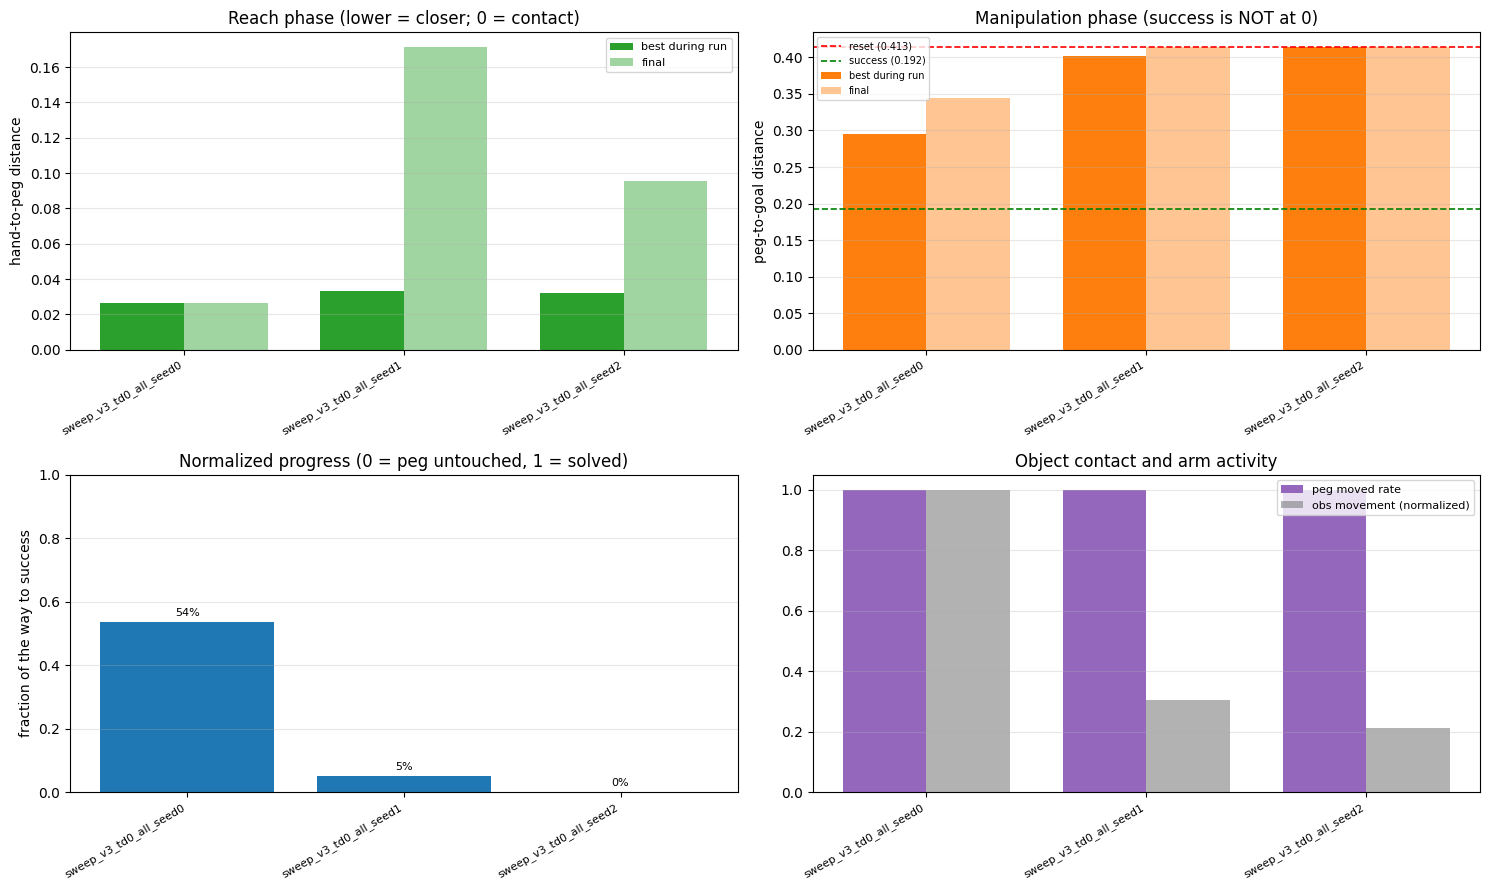

In [35]:
import progress

# --- calibration: measure rather than assume ---
RESET_DIST   = 0.4135     # peg-goal distance at env reset
SUCCESS_DIST = 0.192      # peg-goal distance at the success frame

RUN_GLOB = os.path.join('train_res', 'policy', 'sweep_v3_*')   # any glob
histories = progress.load_run_histories(RUN_GLOB)
print(f'{len(histories)} run(s) found\n')
print(progress.format_progress_table(histories, RESET_DIST, SUCCESS_DIST))

_ = progress.plot_progress_comparison(
    histories, reset_distance=RESET_DIST, success_distance=SUCCESS_DIST,
    save_path=os.path.join('train_res', 'policy', 'progress_comparison.png'))